In [1]:
import sys
import numpy as np
from numpy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import scipy.signal as signal


-0.00046170067, -0.0006826209, -0.00052289446, 9.0989922e-19, 0.00066670505, 0.0010935766, 0.00090502407, -1.4736314e-18, -0.001250687, -0.0020762829, -0.0017179494, 2.4273441e-18, 0.0023232347, 0.0037952333, 0.0030862971, -3.6728746e-18, -0.0040320467, -0.0064817758, -0.0051934653, 5.0820239e-18, 0.0066164049, 0.010529813, 0.0083678022, -6.5097524e-18, -0.010550481, -0.016761257, -0.013331607, 7.8091081e-18, 0.017002164, 0.02733178, 0.022115644, -8.846352e-18, -0.029864374, -0.050256344, -0.043358808, 9.5147237e-18, 0.0740235, 0.15820688, 0.22474334, 0.25, 0.22474334, 0.15820688, 0.0740235, 9.5147237e-18, -0.043358808, -0.050256344, -0.029864374, -8.846352e-18, 0.022115644, 0.02733178, 0.017002164, 7.8091081e-18, -0.013331607, -0.016761257, -0.010550481, -6.5097524e-18, 0.0083678022, 0.010529813, 0.0066164049, 5.0820239e-18, -0.0051934653, -0.0064817758, -0.0040320467, -3.6728746e-18, 0.0030862971, 0.0037952333, 0.0023232347, 2.4273441e-18, -0.0017179494, -0.0020762829, -0.001250687, 

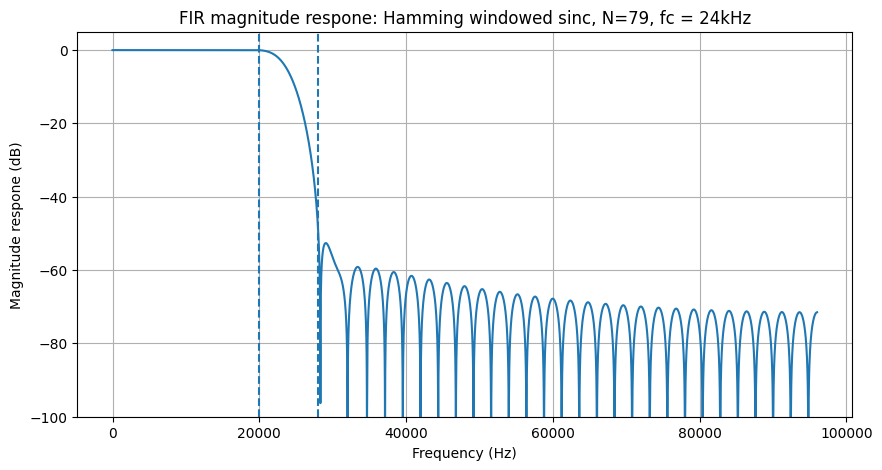

In [2]:
# Interpolation/Decimation Filter Spec: 20kHz - 28kHz transition band, 
# >= 50dB attenuation, L/M = 4, downsample 192kHz -> 48kHz, upsample 48kHz -> 192kHz,  
# Hamming window, k = 3.3 -> N = 3.3 * 192/(28kHz - 20kHz) = 79 taps
# fc = 24kHz

N = 79
fc = 24000
fs = 48000
fs_up = 4 * fs
hamming = signal.windows.hamming(N)
hann = signal.windows.hann(N)
blackman = signal.windows.blackman(N)
n = np.arange(N) - (N - 1) // 2
h_ideal = 2 * fc / fs_up * np.sinc( n * 2 * fc / fs_up )
h_coeffs = h_ideal * hamming

np.set_printoptions(suppress=True, precision=8)
print(', '.join('0' if x == 0 else f'{x:.8g}' for x in h_coeffs))


w, H = signal.freqz( h_coeffs, worN = 8192, fs = fs_up )
plt.figure( figsize = (10, 5))
plt.plot( w, 20 * np.log10(np.abs(H)))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude respone (dB)')
plt.title('FIR magnitude respone: Hamming windowed sinc, N=79, fc = 24kHz')
plt.grid(True)
plt.ylim(-100, 5)
plt.axvline( 20000, linestyle='--' )
plt.axvline( 28000, linestyle='--' )
plt.show()






